### Outcome of inverse = false in the QFT that is not using inverse fourier transform and using fourier transform instead

 In the function e^2*i*x, it is a periodic function with frequency 2, and inverse quantum fourier transform brings it from frequency domain to time domain, and is used for extracting frequency from our data in the form of amplitude. Let's try what's the outcome when inverse is false, that is we are using QFT.

In [1]:
from qiskit import QuantumCircuit, transpile
from qiskit_aer import AerSimulator
from qiskit.visualization import plot_histogram
import numpy as np

In [2]:
from qiskit.quantum_info import Statevector

In [3]:
from qiskit.circuit.library import QFT

In [4]:
n_qubits = 4
num_points = 2**n_qubits
x = np.linspace(0, 2*np.pi, num_points, endpoint=False)
func_values = np.exp(1j*2*x)
normalized_values = func_values / np.linalg.norm(func_values)

In [5]:
qc_exp = QuantumCircuit(n_qubits)
qc_exp.initialize(normalized_values, range(n_qubits))

In [6]:
qft_circ_inv = QFT(4)

Inplace=true just implies that qft_circ_inv is just added to the back of qc_exp and the circuit is modified in place of creating a new circuit and keeping qc_exp unchanged!

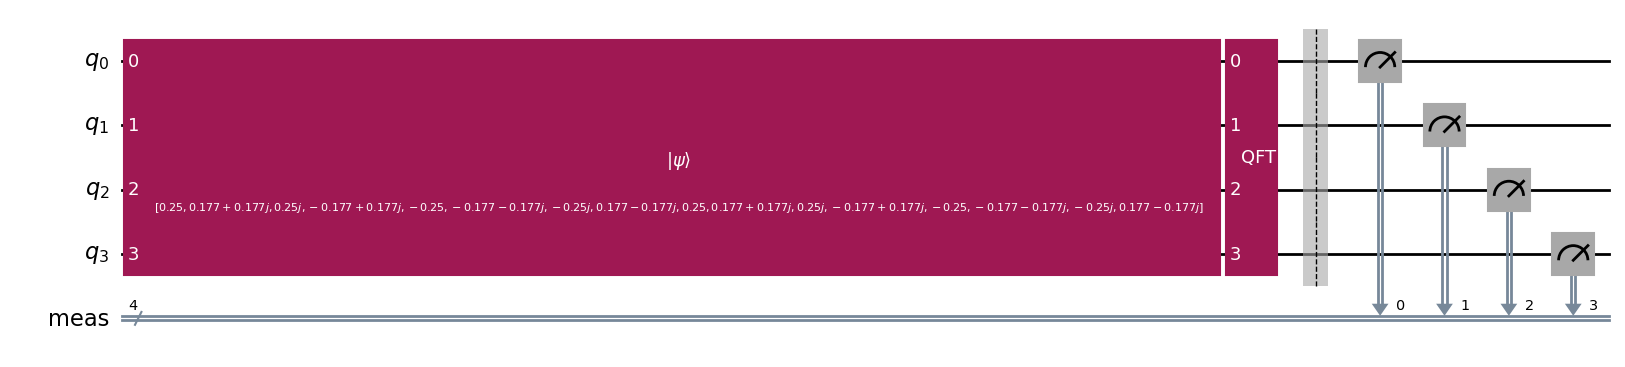

In [7]:
qc_exp.compose(qft_circ_inv, inplace=True) 
qc_exp.measure_all()
qc_exp.draw('mpl')

Creating the transpiled circuit using AerSimulator()

In [8]:
simulator = AerSimulator()
qc_exp_comp = transpile(qc_exp, simulator)
result = simulator.run(qc_exp_comp, shots=1024).result()

Measurement counts: {'1110': 1024}


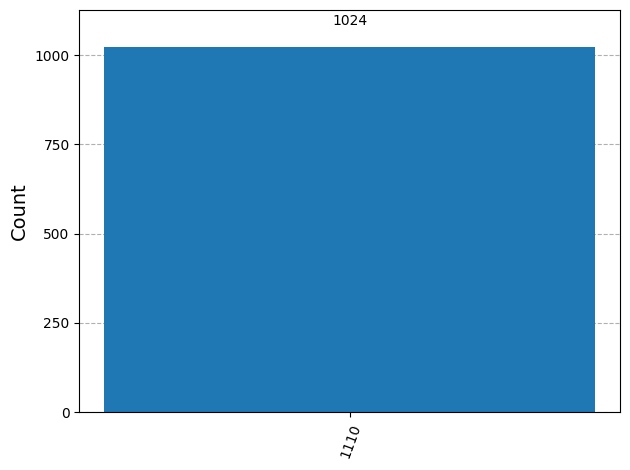

In [9]:
counts = result.get_counts()
print("Measurement counts:", counts)
plot_histogram(counts)

After reading more about it, I figured out, we need IQFT when the frequency is encoded in phase and hence it can't be decoded by QFT. But when the frequency is encoded in basis it can be decoded by QFT. Since the QFT transforms out original state into nearly equal superposition of other basis states. But I don't know why exactly QFT is working here

### Implementation of Fourier Transform of sin2x and sin8x

Put k=2 or k=8 to get sin2x and sin8x

In [10]:
n_qubits_sine = 4
k=2
num_points_sine = 2**n_qubits_sine
x = np.linspace(0, 2*np.pi, num_points_sine, endpoint=False)
func_values_sine = np.sin(k*x)
normalized_values_sine = func_values_sine / np.linalg.norm(func_values_sine)

In [11]:
qc_sine = QuantumCircuit(n_qubits_sine)
qc_sine.initialize(normalized_values_sine, range(n_qubits_sine))

In [12]:
qft_circ_sine = QFT(4)

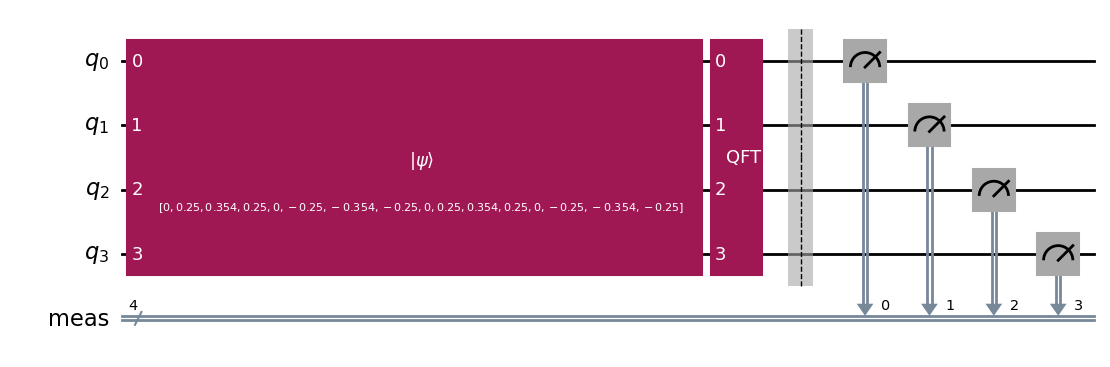

In [13]:
qc_sine.compose(qft_circ_sine, inplace=True)
qc_sine.measure_all()
qc_sine.draw('mpl')

In [14]:
qc_sine_comp = transpile(qc_sine, simulator)
result_sine = simulator.run(qc_sine_comp, shots=1024).result()

Measurement counts: {'0010': 511, '1110': 513}


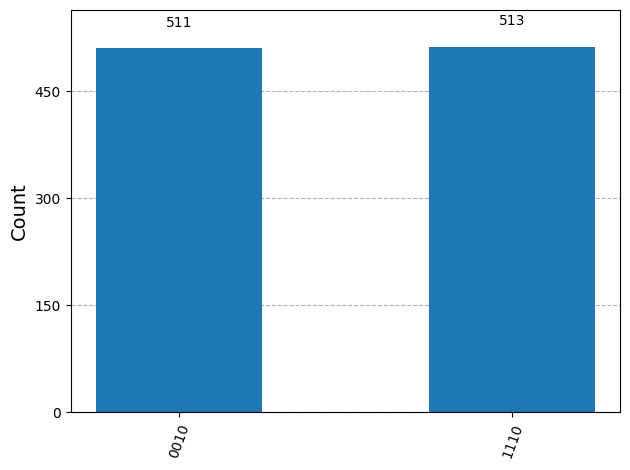

In [15]:
counts_sine = result_sine.get_counts()
print("Measurement counts:", counts_sine)
plot_histogram(counts_sine)

### Why the histogram peaks at 14

The quantum fourier transform takes a function from time domain to frequency domain. And the peaks at 2 and 14 represent the dominant frequencies. Now why 14??

Let's try to see the histogram for Quantum Fourier Transform of sin(-2x), I'll do so by putting k=-2

Surprisingly it gives nearly the same results, now what does this mean? that the major frequency in sin2x and sin(-2x) are same! It is because sin2x=(e^2x - e^-2x)/2 , hence both sin2x and sin(-2x) have a frequency component of 2 and 2^4-2 that is 14!!

### Why not smooth peaks for sin8x!?

Upon putting k=8, and observing the histogram, the highest peak is at 8 followed by 4 and 12; and also a lot of discrete data points. Now why this in the case of sin8x.
Let's do one thing, instead of dividing 2*pi int 16 intervals, I am making change in the above code and dividing pi/2 into 16 intervals and observe what happens! I observed it is working the same as sin2x, Now when I divided 4*pi into 16 intervals I observed the peak at 0 due to mutual cancellation. Let's try changing the value of N to 64; Now I observe 2 clear bars in histogram that of 8 and 56(-8) basically and I get my required result. But why does this happen!?

It may be because in case of higher frequency, a greater value of N gives a better resolution; that is 1/64 is obviously better than 1/16.

### Amplitude Encoding and it's Alternatives

Basis Encoding: just like digital encoding it involves converting into 0,1 basis. For example 3=|11>; that is basically converting into basis states. But it requires a lot of qubits and hence expensive.

Amplitude Encoding: It involves encoding qubits in the form of the amplitudes of their basis qubit states. For example, |x> = a|0> +b|1>, is an example of amplitude encoding in the form of amplitudes as a^2 + b^2 = 1. It is hard to calculate and hence less preferred.

Hamiltonian encoding: This hamiltonian operator is the same as mentioned in quantum mechanics as -i(h/2*pi)*(dy/dx). We encode our information not in the quantum state, but in the Hamiltonian. By encoding our data into H, we can also understand the time evolution of our state. 

# Quantum Phase Estimation

## Estimating Excited State Energy

### Question1

In [16]:
import base64

with open("theta.txt", "r") as f:
    encoded_theta = f.read()

theta = float(base64.b64decode(encoded_theta).decode())
phi = (2 * np.pi * theta) / 4


qc_qpe = QuantumCircuit(2)
qc_qpe.x(1)

power = 2
qc_qpe.cp(theta=2**power*2*np.pi*theta, control_qubit=0, target_qubit=1)

In quantum phase estimation, our theta should be from 0 to 1; but in the question we are given theta is less than 4, hence we create another variable phi, estimate phi and then multiply by 4!

### Question2

I'm using 2 control qubits and 1 target qubit to implement QPE

In [46]:
c=4
qc_qpe=QuantumCircuit(c+1, c)

First apply hadamard on control qubits

In [47]:
for qubit in range(c):
    qc_qpe.h(qubit)

Since the eigen vector is |1>

In [48]:
qc_qpe.x(c)

Value of theta already decrypted & Applying U and U^2 gate now; here j are the control qubits which are basically 0 and 1 & c is the target qubit which is the 2nd qubit.

In [49]:
for j in range(c):
    angle = 2 * np.pi * theta * (2 ** j) / 4
    qc_qpe.cp(angle, j, c) 

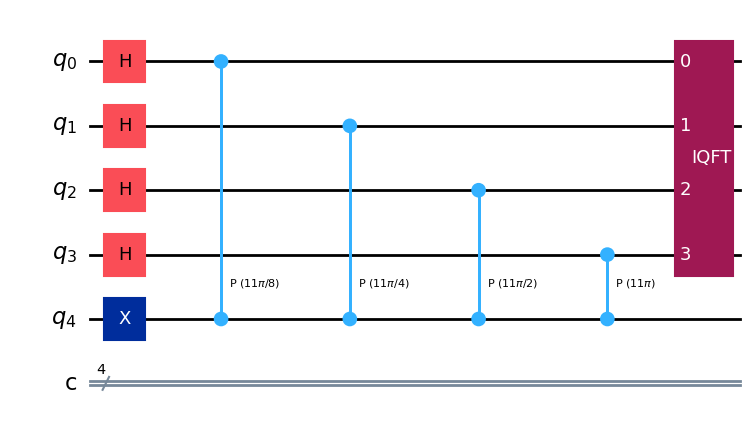

In [51]:
q_qpe=QFT(4, inverse=True)
qc_qpe.append(q_qpe, range(4))
qc_qpe.draw('mpl')

In [52]:
state=Statevector.from_int(0, 2**5)
state=state.evolve(qc_qpe)
state.draw('latex')

<IPython.core.display.Latex object>

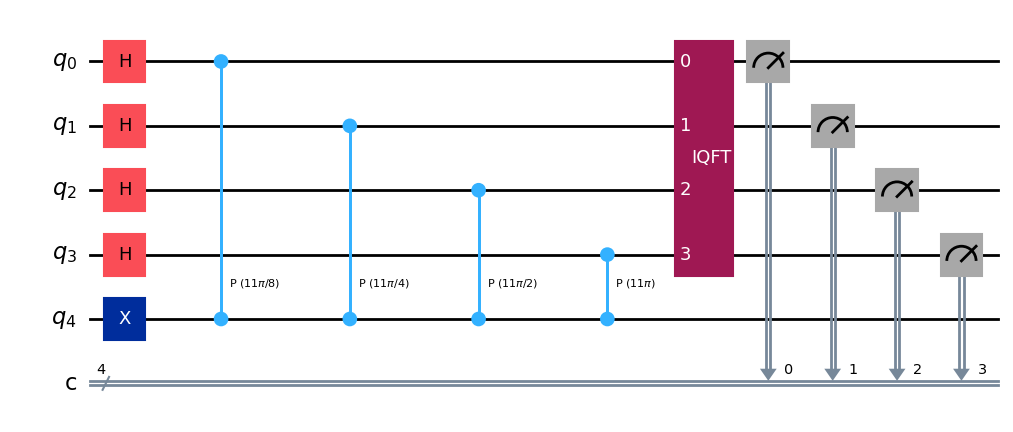

In [53]:
for i in range(c):
    qc_qpe.measure(i, i)
qc_qpe.draw('mpl')

In [54]:
simulator=AerSimulator()
compiled_circuit=transpile(qc_qpe, simulator)
result=simulator.run(compiled_circuit, shots=2048).result()
counts=result.get_counts()

### Question 3

Measurement Counts :  {'1011': 2048}


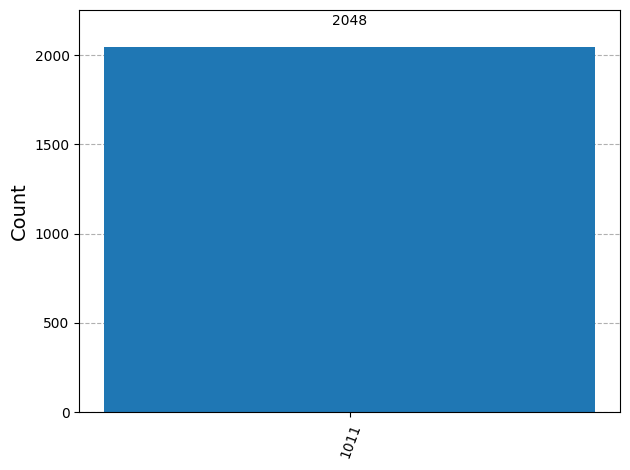

In [55]:
print("Measurement Counts : ",  counts)
plot_histogram(counts)

We got the basis 01 as the highest priority which was indeed the case! Now what about theta?

In [56]:
measured_binary = max(counts, key=counts.get)
print(measured_binary)
# which is indeed equal to observation

1011


In [57]:
c = 4
measured_decimal = int(measured_binary, 2) #converts binary to decimal
phase = measured_decimal / (2**c)

In [58]:
theta_new = phase * 4
print(theta_new)

2.75


theta is indeed coming in the given range, we can also find more precise values of theta by increasing the number of control qubits